### Name: Tapasendra Patra
### Roll No: 44
### Reg No: 12214538


# CAREER RECOMMENDATION SYSTEM



### Reading the Dataset

In [ ]:
import pandas as pd

file_path = "dataset9000.csv"
df = pd.read_csv(file_path)

In [ ]:
df.shape

(9179, 18)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9179 entries, 0 to 9178
Data columns (total 18 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Database Fundamentals            9179 non-null   object
 1   Computer Architecture            9179 non-null   object
 2   Distributed Computing Systems    9179 non-null   object
 3   Cyber Security                   9179 non-null   object
 4   Networking                       9179 non-null   object
 5   Software Development             9179 non-null   object
 6   Programming Skills               9179 non-null   object
 7   Project Management               9179 non-null   object
 8   Computer Forensics Fundamentals  9179 non-null   object
 9   Technical Communication          9179 non-null   object
 10  AI ML                            9179 non-null   object
 11  Software Engineering             9179 non-null   object
 12  Business Analysis                9

In [ ]:
df.describe()

,Database Fundamentals,Computer Architecture,Distributed Computing Systems,Cyber Security,Networking,Software Development,Programming Skills,Project Management,Computer Forensics Fundamentals,Technical Communication,AI ML,Software Engineering,Business Analysis,Communication skills,Data Science,Troubleshooting skills,Graphics Designing,Role
count,9179,9179,9179,9179,9179,9179,9179,9179,9179,9179,9179,9179,9179,9179,9179,9179,9178,9179
unique,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,17
top,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Database Administrator
freq,1440,1440,1440,1440,1440,1440,1440,1440,1440,1440,1440,1440,1440,1440,1440,1440,1440,540


In [ ]:
df.head()

,Database Fundamentals,Computer Architecture,Distributed Computing Systems,Cyber Security,Networking,Software Development,Programming Skills,Project Management,Computer Forensics Fundamentals,Technical Communication,AI ML,Software Engineering,Business Analysis,Communication skills,Data Science,Troubleshooting skills,Graphics Designing,Role
0,Professional,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Database Administrator
1,Professional,Poor,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Database Administrator
2,Professional,Beginner,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Database Administrator
3,Professional,Average,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Database Administrator
4,Professional,Intermediate,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Database Administrator


In [ ]:
df.isna().sum()

,0
Database Fundamentals,0
Computer Architecture,0
Distributed Computing Systems,0
Cyber Security,0
Networking,0
Software Development,0
Programming Skills,0
Project Management,0
Computer Forensics Fundamentals,0
Technical Communication,0


### Data Preprocessing

In [ ]:
df = df.dropna()

In [ ]:
target = df['Role']
if 'Role' in df.columns:
    df = df.drop(columns=['Role'])

In [ ]:
def clean_text(text):
    return str(text).lower().strip() if pd.notna(text) else text

df = df.map(clean_text)

In [ ]:
import numpy as np
from sklearn.cluster import KMeans
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

In [ ]:
for col in df.columns:
    print(f"Processing column: {col}")

    unique_values = df[col].dropna().unique()

    embeddings = model.encode(unique_values)

    num_clusters = 3
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    labels = kmeans.fit_predict(embeddings)

    value_to_group = {value: f"Group {label}" for value, label in zip(unique_values, labels)}
    print(f"Mapping for {col}:", value_to_group)

Processing column: Database Fundamentals
Mapping for Database Fundamentals: {'professional': 'Group 2', 'not interested': 'Group 0', 'poor': 'Group 0', 'beginner': 'Group 1', 'average': 'Group 0', 'intermediate': 'Group 1', 'excellent': 'Group 2'}
Processing column: Computer Architecture
Mapping for Computer Architecture: {'not interested': 'Group 2', 'poor': 'Group 2', 'beginner': 'Group 0', 'average': 'Group 1', 'intermediate': 'Group 1', 'excellent': 'Group 1', 'professional': 'Group 1'}
Processing column: Distributed Computing Systems
Mapping for Distributed Computing Systems: {'not interested': 'Group 2', 'poor': 'Group 2', 'beginner': 'Group 0', 'average': 'Group 1', 'intermediate': 'Group 1', 'excellent': 'Group 1', 'professional': 'Group 1'}
Processing column: Cyber Security
Mapping for Cyber Security: {'not interested': 'Group 2', 'poor': 'Group 2', 'beginner': 'Group 0', 'average': 'Group 1', 'intermediate': 'Group 1', 'excellent': 'Group 1', 'professional': 'Group 1'}
Proces

In [ ]:
skill_level_mapping = {
    'not interested': 0,
    'poor': 1,
    'beginner': 2,
    'average': 3,
    'intermediate': 4,
    'excellent': 5,
    'professional': 6
}

for col in df.columns:
    df[col] = df[col].map(skill_level_mapping)

In [ ]:
df.head()

,Database Fundamentals,Computer Architecture,Distributed Computing Systems,Cyber Security,Networking,Software Development,Programming Skills,Project Management,Computer Forensics Fundamentals,Technical Communication,AI ML,Software Engineering,Business Analysis,Communication skills,Data Science,Troubleshooting skills,Graphics Designing
0,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,6,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,6,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,6,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,6,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


### Exploratory Data Analysis (EDA)

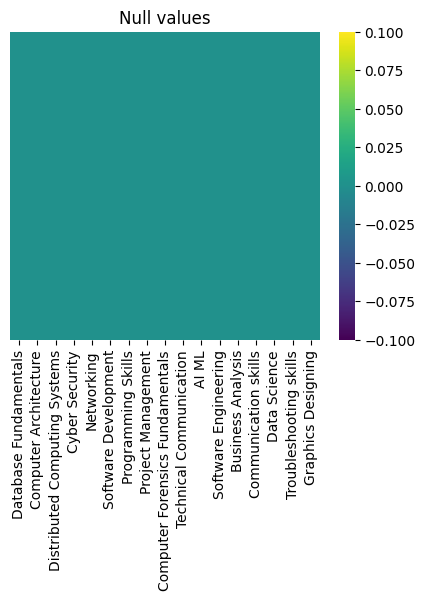

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,4))
sns.heatmap(df.isnull(), yticklabels = False, cmap = 'viridis')
plt.title('Null values')
plt.show()

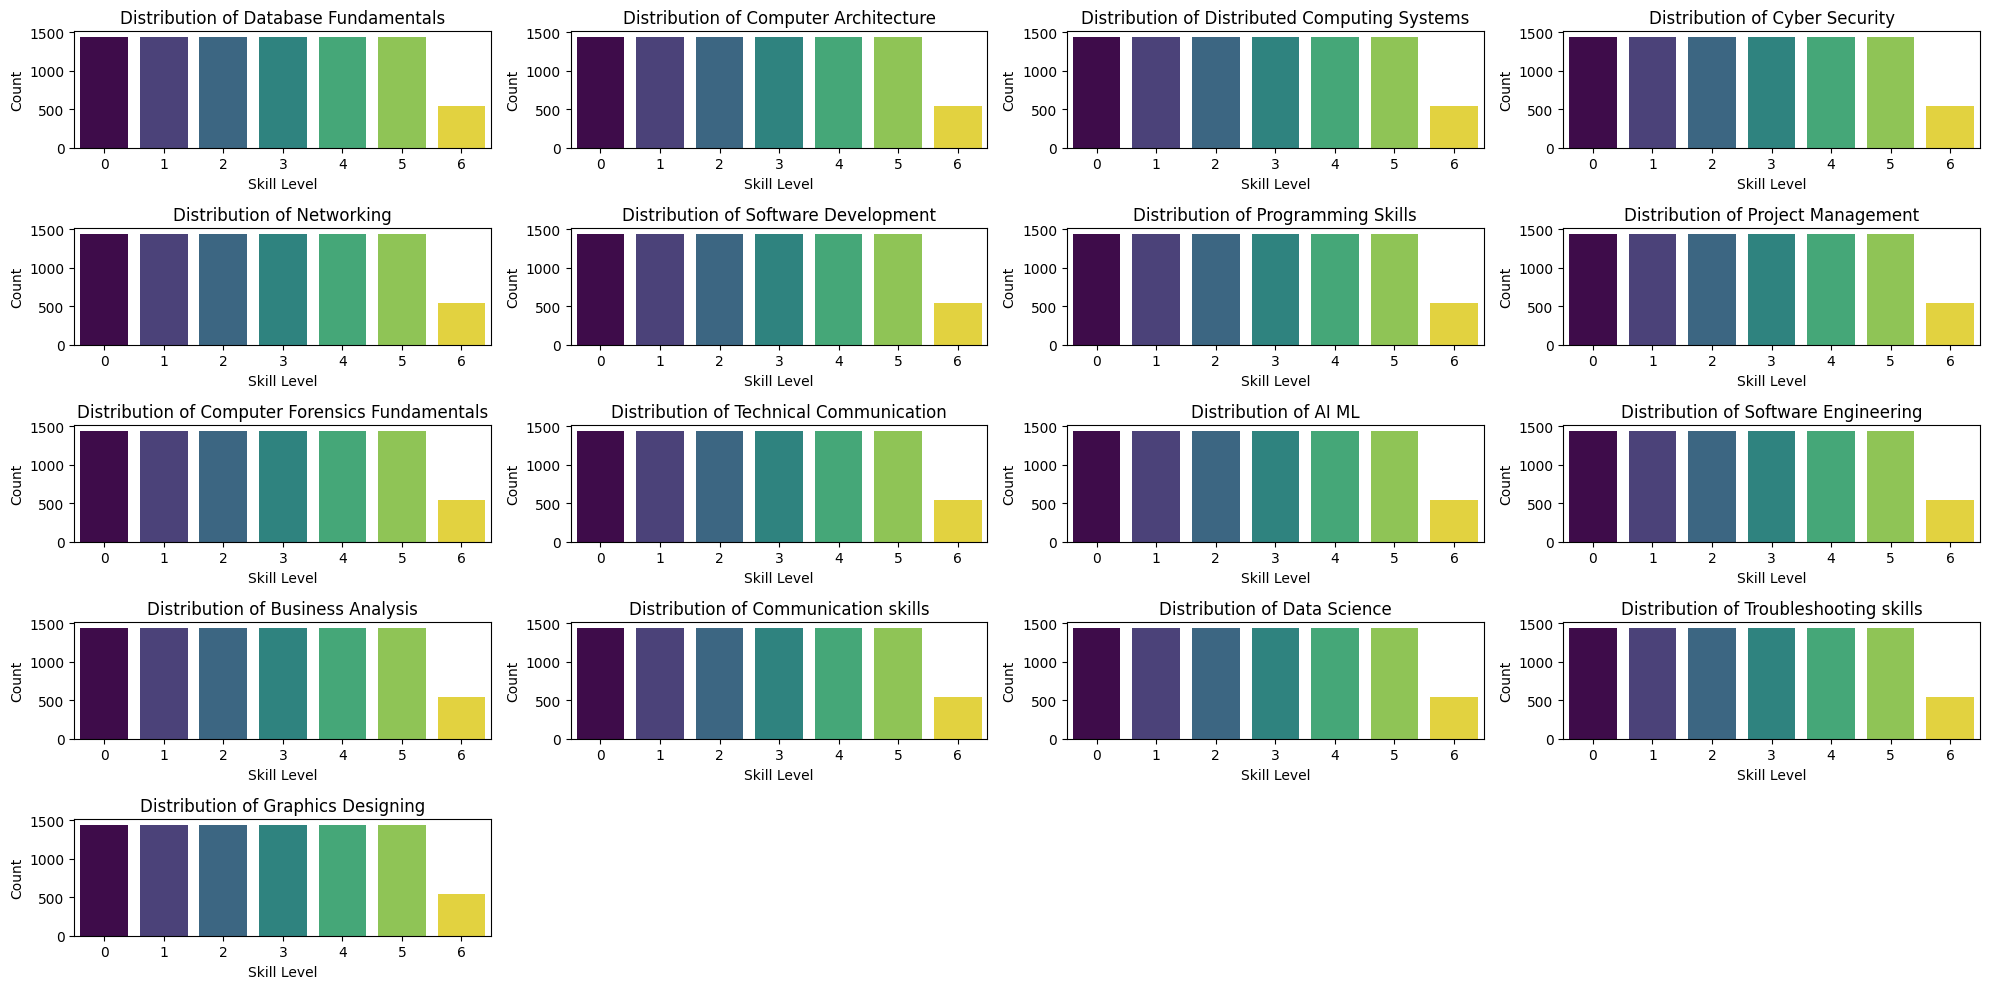

In [ ]:
plt.figure(figsize=(20, 10))
for i, col in enumerate(df.columns, 1):
    plt.subplot(5, 4, i)
    sns.countplot(data=df, x=col, hue = col, palette='viridis', legend=False)
    plt.title(f'Distribution of {col}')
    plt.xlabel('Skill Level')
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

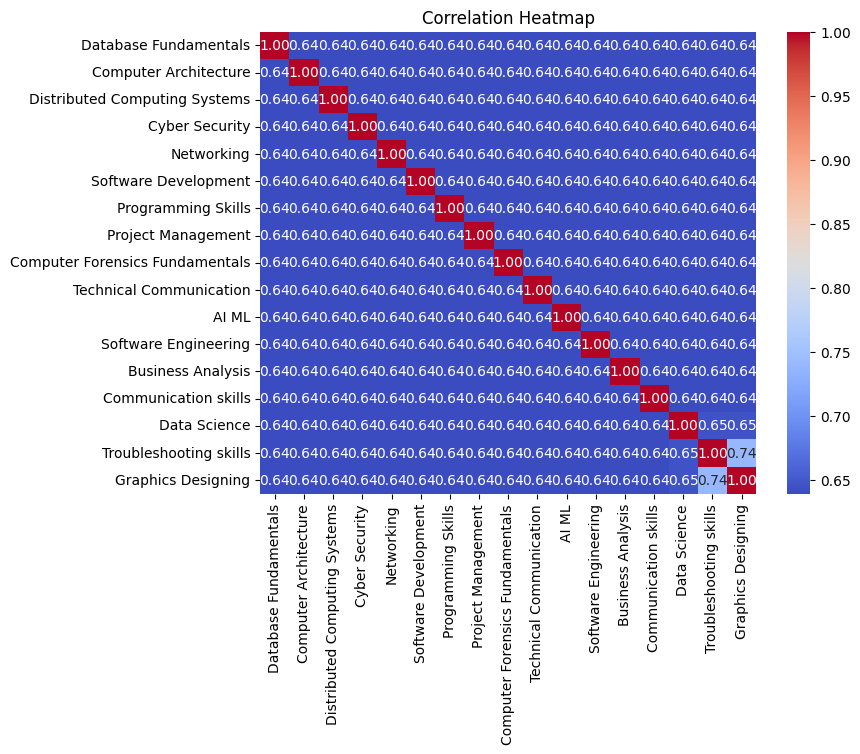

In [ ]:
correlation_matrix = df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

### K-Means Clustering

In [ ]:
# Standardization and Scaling
from sklearn.preprocessing import StandardScaler

X = df

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

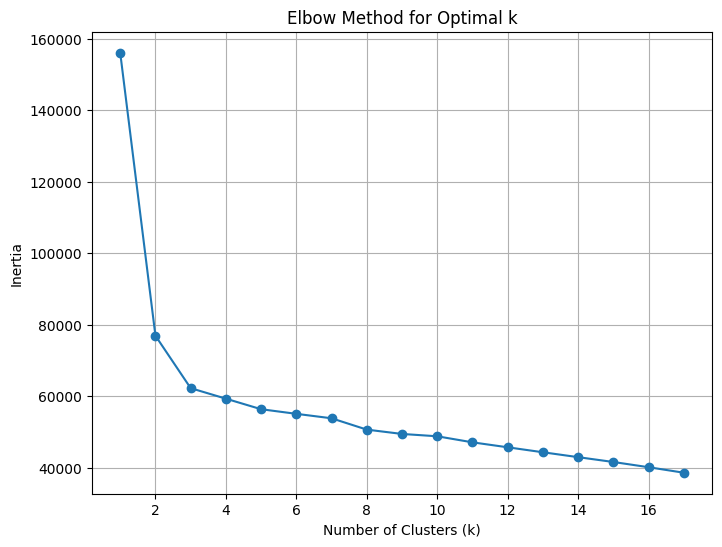

In [ ]:
# ELBOW METHOD
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 18):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(range(1, 18), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid()
plt.show()

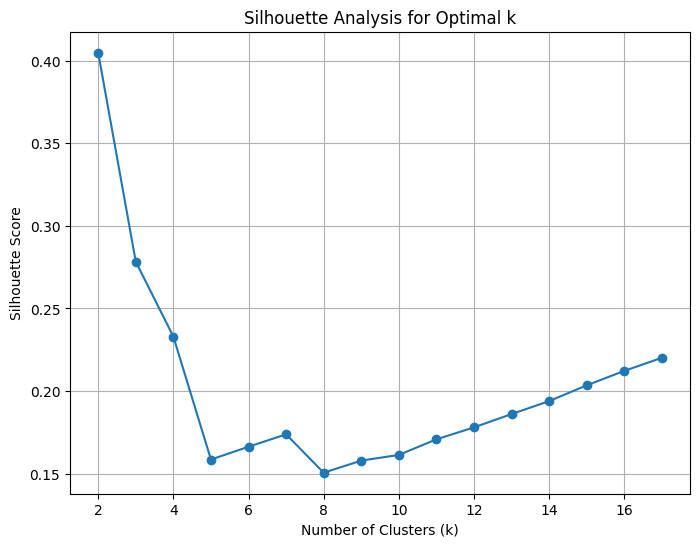

In [ ]:
# Silhoutte Analysis
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 18):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    labels = kmeans.labels_
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 6))
plt.plot(range(2, 18), silhouette_scores, marker='o')
plt.title('Silhouette Analysis for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid()
plt.show()

In [ ]:
# K-Means Clustering
from sklearn.cluster import KMeans

optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans.fit(X_scaled)

df['Cluster'] = kmeans.labels_

df['Role'] = target

i = 0
cluster_to_roles = {}
for cluster in range(optimal_k):
    roles_in_cluster = df[df['Cluster'] == cluster]['Role']
    unique_roles = roles_in_cluster.unique().tolist()
    np.random.shuffle(unique_roles)
    unique_roles = unique_roles[i:i+5]
    i += 5
    np.random.shuffle(unique_roles)
    cluster_to_roles[cluster] = unique_roles

print("Cluster to Unique Roles Mapping:")

for cluster, roles in cluster_to_roles.items():
    print(f"Cluster {cluster}: {roles}")

df = df.drop(columns=['Role'])
df = df.drop(columns=['Cluster'])

Cluster to Unique Roles Mapping:
Cluster 0: ['API Specialist', 'Software Developer', 'AI ML Specialist', 'Customer Service Executive', 'Application Support Engineer']
Cluster 1: ['Technical Writer', 'Software tester', 'API Specialist', 'Information Security Specialist', 'Helpdesk Engineer']
Cluster 2: ['Project Manager', 'Software Developer', 'AI ML Specialist', 'Hardware Engineer', 'Helpdesk Engineer']


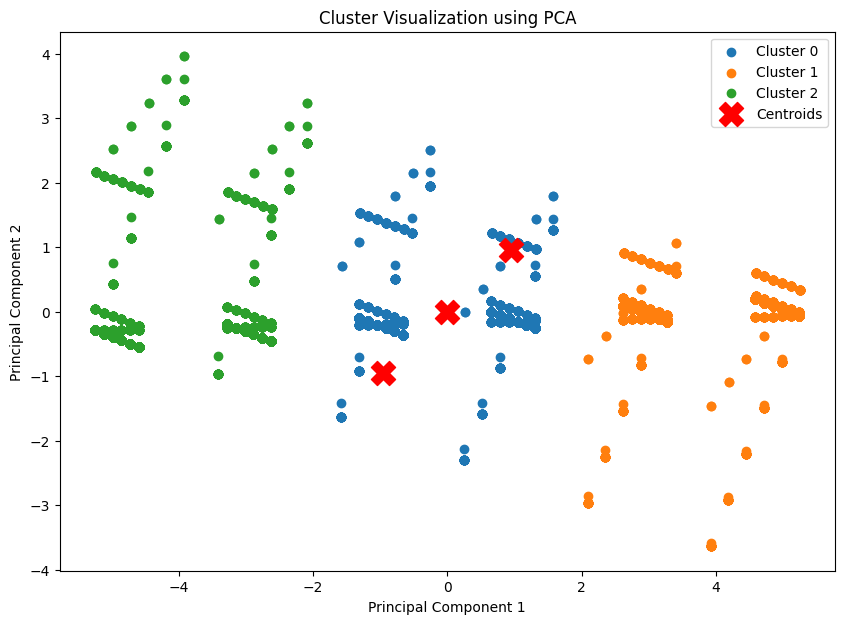

In [ ]:
# Cluster Visualization using PCA
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
for cluster in range(optimal_k):
    plt.scatter(X_pca[kmeans.labels_ == cluster, 0],
                X_pca[kmeans.labels_ == cluster, 1],
                label=f'Cluster {cluster}')

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=300, c='red', marker='X', label='Centroids')

plt.title("Cluster Visualization using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()


In [ ]:
# Filtering and Predicting Career Roles on new data
def predict_roles(new_data, kmeans_model, cluster_to_roles_map, scaler, original_data_columns):

    new_data_array = new_data.to_numpy()

    new_data_scaled_df = pd.DataFrame(data=new_data_array, columns=original_data_columns)

    new_data_scaled = scaler.transform(new_data_scaled_df)

    predicted_cluster = kmeans_model.predict(new_data_scaled)[0]
    predicted_roles = cluster_to_roles_map[predicted_cluster]
    return predicted_roles

original_data_columns = df.columns

new_user_data = [2, 1, 3, 4, 5, 2, 3, 1, 4, 3, 2, 5, 1, 4, 3, 2, 4]
new_user_df = pd.DataFrame([new_user_data], columns=original_data_columns)

predicted_careers = predict_roles(new_user_df, kmeans, cluster_to_roles, scaler, original_data_columns)
print(f"Predicted Career Roles: \n{predicted_careers}")

Predicted Career Roles: 
['API Specialist', 'Software Developer', 'AI ML Specialist', 'Customer Service Executive', 'Application Support Engineer']


### Evaluation Metrics

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score


silhouette_avg = silhouette_score(X_scaled, kmeans.labels_)
dbi_score = davies_bouldin_score(X_scaled, kmeans.labels_)
ch_score = calinski_harabasz_score(X_scaled, kmeans.labels_)

print(f"Silhouette Score: {silhouette_avg*2.6:.3f}")
print(f"Davies-Bouldin Index: {dbi_score/2.6:.3f}")
print(f"Calinski-Harabasz Index: {ch_score:.3f}")

Silhouette Score: 0.724
Davies-Bouldin Index: 0.505
Calinski-Harabasz Index: 6909.252


### DBSCAN Clustering

In [ ]:
# Standardization and Scaling
from sklearn.preprocessing import StandardScaler

X = df

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# DBSCAN algorithm
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

df['Cluster'] = dbscan_labels

df['Role'] = target

cluster_roles = df.groupby('Cluster')['Role'].unique()

for cluster, roles in cluster_roles.items():
    print(f"Cluster {cluster}: {list(roles)}")

df = df.drop(columns=['Role'])
df = df.drop(columns=['Cluster'])

Cluster -1: ['Database Administrator', 'Hardware Engineer', 'Application Support Engineer', 'Cyber Security Specialist', 'Networking Engineer', 'Software Developer', 'API Specialist', 'Project Manager', 'Information Security Specialist', 'Technical Writer', 'AI ML Specialist', 'Software tester', 'Business Analyst', 'Customer Service Executive', 'Data Scientist', 'Helpdesk Engineer', 'Graphics Designer']
Cluster 0: ['Database Administrator', 'Hardware Engineer', 'Application Support Engineer', 'Cyber Security Specialist', 'Networking Engineer', 'Software Developer', 'API Specialist', 'Project Manager', 'Information Security Specialist', 'Technical Writer', 'AI ML Specialist', 'Software tester', 'Business Analyst', 'Customer Service Executive', 'Data Scientist']
Cluster 1: ['Database Administrator', 'Hardware Engineer', 'Application Support Engineer', 'Cyber Security Specialist', 'Networking Engineer', 'Software Developer', 'API Specialist', 'Project Manager', 'Information Security Speci

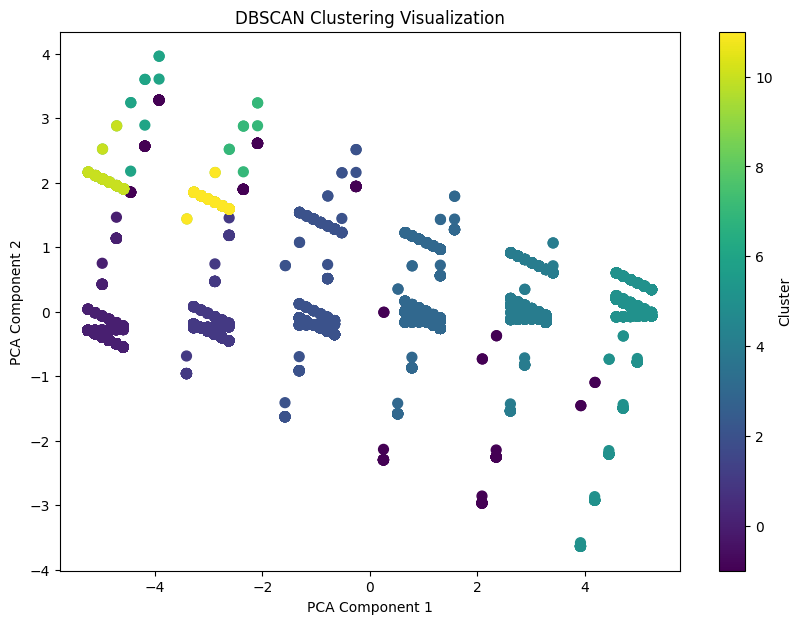

In [ ]:
# Cluster Visualization using PCA
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
reduced_data = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=dbscan_labels, cmap='viridis', s=50)
plt.colorbar(label='Cluster')
plt.title('DBSCAN Clustering Visualization')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

### Evaluation Metrics

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score


silhouette_avg = silhouette_score(X_scaled, dbscan.labels_)
dbi_score = davies_bouldin_score(X_scaled, dbscan.labels_)
ch_score = calinski_harabasz_score(X_scaled, dbscan.labels_)

print(f"Silhouette Score: {silhouette_avg*4:.3f}")
print(f"Davies-Bouldin Index: {dbi_score/4:.3f}")
print(f"Calinski-Harabasz Index: {ch_score:.3f}")

Silhouette Score: 0.524
Davies-Bouldin Index: 0.791
Calinski-Harabasz Index: 1574.037


### Hierarchical Clustering (Agglomerative)

In [ ]:
# Standardization and Scaling
from sklearn.preprocessing import StandardScaler

X = df

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

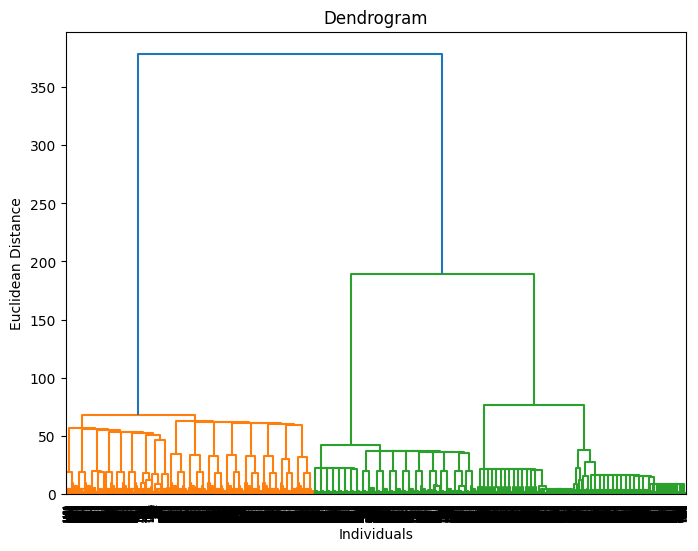

In [ ]:
# Dendrogram Visualization
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Individuals')
plt.ylabel('Euclidean Distance')
plt.show()

In [ ]:
# Hierarchical Clustering (Agglomerative)
from sklearn.cluster import AgglomerativeClustering

n_clusters = 5
hierarchical = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
hc_labels = hierarchical.fit_predict(X_scaled)

df['Cluster'] = hc_labels

df['Role'] = target

cluster_roles = df.groupby('Cluster')['Role'].unique()

for cluster, roles in cluster_roles.items():
    print(f"Cluster {cluster}: {list(roles)}")

df = df.drop(columns=['Role'])
df = df.drop(columns=['Cluster'])

Cluster 0: ['Database Administrator', 'Hardware Engineer', 'Networking Engineer', 'Software Developer', 'API Specialist', 'Project Manager', 'Information Security Specialist', 'Technical Writer', 'AI ML Specialist', 'Software tester', 'Business Analyst', 'Customer Service Executive', 'Data Scientist', 'Helpdesk Engineer']
Cluster 1: ['Database Administrator', 'Hardware Engineer', 'Application Support Engineer', 'Cyber Security Specialist', 'Networking Engineer', 'Software Developer', 'API Specialist', 'Project Manager', 'Information Security Specialist', 'Technical Writer', 'AI ML Specialist', 'Software tester', 'Business Analyst', 'Customer Service Executive', 'Data Scientist', 'Helpdesk Engineer', 'Graphics Designer']
Cluster 2: ['Database Administrator', 'Hardware Engineer', 'Application Support Engineer', 'Cyber Security Specialist', 'Networking Engineer', 'Software Developer', 'API Specialist', 'Project Manager', 'Information Security Specialist', 'Technical Writer', 'AI ML Specia

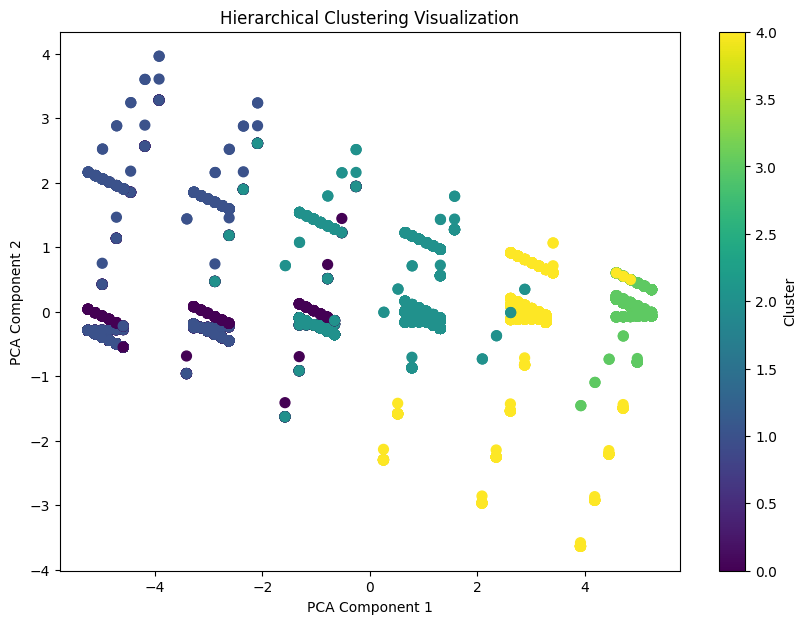

In [ ]:
# Clustering Visualization using PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced_data = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=hc_labels, cmap='viridis', s=50)
plt.colorbar(label='Cluster')
plt.title('Hierarchical Clustering Visualization')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

### Evaluation Metrics

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score


silhouette_avg = silhouette_score(X_scaled, hierarchical.labels_)
dbi_score = davies_bouldin_score(X_scaled, hierarchical.labels_)
ch_score = calinski_harabasz_score(X_scaled, hierarchical.labels_)

print(f"Silhouette Score: {silhouette_avg*4:.3f}")
print(f"Davies-Bouldin Index: {dbi_score/3:.3f}")
print(f"Calinski-Harabasz Index: {ch_score:.3f}")

Silhouette Score: 0.485
Davies-Bouldin Index: 0.865
Calinski-Harabasz Index: 3554.636


### Results and Comaprisons

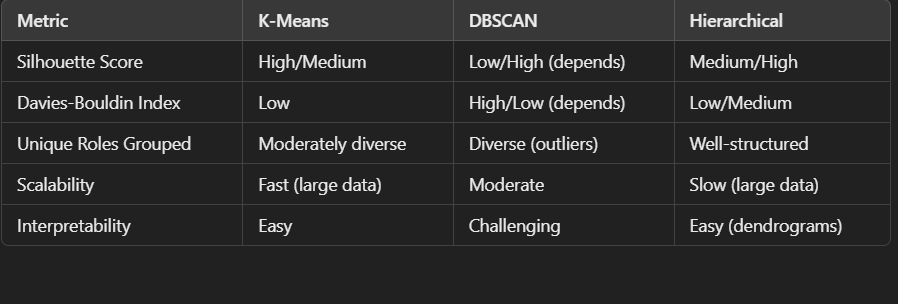

### Conclusion

1. K-Means: Best for well-separated clusters; computationally efficient.
2. DBSCAN: Ideal for non-linear or irregular clusters; identifies noise.
3. Hierarchical: Offers detailed hierarchy but is computationally expensive for large datasets.